# Fase 2 - EDA Forensik
**Project:** Lapis AI - Predictive Maintenance
**Tujuan:** Eksplorasi mendalam pola failure, distribusi sensor, dan korelasi antar fitur untuk memandu strategi Label Engineering di Fase 3.

> Semua path dan parameter bersumber dari `src/config.py`. Tidak ada hardcode di notebook ini.

| Cell | Konten |
|------|--------|
| **1** | Setup, Load Data, Isolasi Failure |
| **2** | Failure Autopsy Visualization (3 mesin x 8 sensor) |
| **3** | Sensor Informativeness Test (Boxplot + Cohen's d) |

In [ ]:
# ============================================================
# FASE 2 - EDA FORENSIK
# Cell 1: Setup, Load Data, Isolasi Failure
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# Notebook berada di: notebooks/fase_2_eda/
# ML_ROOT = dua level ke atas
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent   # machine_learning/
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ----------------------------------------------------------
# [2] IMPORT CONFIG - single source of truth
# ----------------------------------------------------------
from config import SENSOR_FILE, MAINTENANCE_FILE, GLOBAL_SEED

# ----------------------------------------------------------
# [3] GLOBAL SETTINGS
# ----------------------------------------------------------
np.random.seed(GLOBAL_SEED)

sns.set_style("darkgrid")
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "font.size"     : 11,
})

# ----------------------------------------------------------
# [4] LOAD DATA
# ----------------------------------------------------------
df_sensor = pd.read_csv(
    SENSOR_FILE,
    parse_dates=["timestamp"],
    dtype={"machine_id": str},
)

df_maintenance = pd.read_csv(
    MAINTENANCE_FILE,
    parse_dates=["date"],
)

# ----------------------------------------------------------
# [5] KONFIRMASI SETUP
# ----------------------------------------------------------
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  SETUP KONFIRMASI")
print(SEP)
print(f"  SRC_PATH       : {SRC_PATH}")
print(f"  GLOBAL_SEED    : {GLOBAL_SEED}")
print(f"  SENSOR_FILE    : {SENSOR_FILE.name}  shape={df_sensor.shape}")
print(f"  MAINTENANCE    : {MAINTENANCE_FILE.name}  shape={df_maintenance.shape}")
print(f"  Seaborn style  : darkgrid")
print(f"  Figure size    : {plt.rcParams['figure.figsize']}")
print(f"  Font size      : {plt.rcParams['font.size']}")

# ============================================================
# ISOLASI FAILURE
# ============================================================
df_failures = df_sensor[df_sensor["failure"] == 1].copy()

print(f"\n{SEP}")
print("  ISOLASI FAILURE")
print(SEP)

# [A] Total kejadian failure
total_failures   = len(df_failures)
total_rows       = len(df_sensor)
failure_rate_pct = total_failures / total_rows * 100

print(f"\n  Total baris df_sensor       : {total_rows:,}")
print(f"  Total kejadian failure (=1) : {total_failures:,}")
print(f"  Failure rate                : {failure_rate_pct:.4f}%")

# [B] Tabel ringkasan per machine_id
print(f"\n{sep}")
print("  TABEL RINGKASAN FAILURE PER MESIN")
print(sep)

summary_per_machine = (
    df_failures
    .groupby("machine_id", sort=True)
    .agg(
        jumlah_failure=("failure", "count"),
        timestamp_failure_pertama=("timestamp", "min"),
        timestamp_failure_terakhir=("timestamp", "max"),
    )
    .reset_index()
    .sort_values("machine_id", ascending=True)
)

summary_per_machine["timestamp_failure_pertama"] = (
    summary_per_machine["timestamp_failure_pertama"].dt.strftime("%Y-%m-%d %H:%M")
)
summary_per_machine["timestamp_failure_terakhir"] = (
    summary_per_machine["timestamp_failure_terakhir"].dt.strftime("%Y-%m-%d %H:%M")
)

print()
print(summary_per_machine.to_string(index=False))

# [C] Distribusi failure per bulan
print(f"\n{sep}")
print("  DISTRIBUSI FAILURE PER BULAN")
print(sep)

failure_per_bulan = (
    df_failures
    .groupby(df_failures["timestamp"].dt.to_period("M"))["failure"]
    .count()
    .rename_axis("periode")
    .reset_index(name="jumlah_failure")
)
failure_per_bulan["pct_%"] = (
    failure_per_bulan["jumlah_failure"] / total_failures * 100
).round(2)

print()
print(failure_per_bulan.to_string(index=False))

print(f"\n{SEP}")
print("  [OK] Setup & Isolasi Failure selesai. Siap untuk EDA visualisasi.")
print(SEP)

---
## Failure Autopsy Visualization
Visualisasi 72 jam sebelum failure untuk 3 mesin representatif.
Setiap figure menampilkan 8 subplot sensor dengan marker waktu kritis:

| Marker | Warna | Keterangan |
|--------|-------|------------|
| `FAILURE` | Merah solid | Titik failure aktual |
| `T-24h` | Oranye dashed | 24 jam sebelum failure |
| `T-48h` | Kuning dotted | 48 jam sebelum failure |
| Shading | Merah alpha=0.1 | Window kritis 24 jam terakhir |

In [ ]:
# ============================================================
# FASE 2 - FAILURE AUTOPSY VISUALIZATION
# Cell 2: 3 Mesin x 8 Sensor - 72-jam Look-back Window
# ============================================================

# ----------------------------------------------------------
# SETUP ANALISIS
# ----------------------------------------------------------
MACHINES_TO_ANALYZE = [
    "M-01",   # machine_a - 4x failure
    "M-09",   # machine_b - 2x failure
    "M-05",   # machine_c - 1x failure
]

LOOK_BACK_HRS = 72

SENSOR_COLS = [
    "temperature",
    "vibration",
    "pressure",
    "rpm",
    "power_consumption",
    "noise_level",
    "humidity",
    "operating_hours",
]

# Verifikasi kolom sensor tersedia di df_sensor (defensive)
sensor_cols_ok      = [c for c in SENSOR_COLS if c in df_sensor.columns]
sensor_cols_missing = [c for c in SENSOR_COLS if c not in df_sensor.columns]

if sensor_cols_missing:
    print(f"[WARN] Kolom tidak ditemukan (dilewati): {sensor_cols_missing}")

print(f"[INFO] Sensor yang akan diplot : {sensor_cols_ok}")
print(f"[INFO] Look-back window        : {LOOK_BACK_HRS} jam")
print(f"[INFO] Mesin yang dianalisis   : {MACHINES_TO_ANALYZE}")
print()

# ----------------------------------------------------------
# HELPER: ambil T_failure pertama untuk satu machine_id
# ----------------------------------------------------------
def get_first_failure_ts(machine_id):
    """Kembalikan timestamp failure pertama untuk machine_id tertentu."""
    mask   = df_failures["machine_id"] == machine_id
    subset = df_failures.loc[mask, "timestamp"]
    if subset.empty:
        raise ValueError(f"Tidak ada data failure untuk machine_id='{machine_id}'")
    return subset.min()


# ----------------------------------------------------------
# MAIN LOOP - satu figure per mesin
# ----------------------------------------------------------
for machine_id in MACHINES_TO_ANALYZE:

    # [1] Ambil T_failure pertama
    T_failure      = get_first_failure_ts(machine_id)
    T_window_start = T_failure - pd.Timedelta(hours=LOOK_BACK_HRS)
    T_minus_24h    = T_failure - pd.Timedelta(hours=24)
    T_minus_48h    = T_failure - pd.Timedelta(hours=48)

    # [2] Filter df_sensor untuk mesin ini
    df_machine = df_sensor[df_sensor["machine_id"] == machine_id].copy()

    # [3] Ambil window data
    df_window = df_machine[
        (df_machine["timestamp"] >= T_window_start) &
        (df_machine["timestamp"] <= T_failure)
    ].sort_values("timestamp")

    n_points = len(df_window)
    print(f"  [{machine_id}]  T_failure={T_failure}  |  Data dalam window: {n_points} baris")

    if n_points == 0:
        print(f"  [SKIP] Tidak ada data dalam window {LOOK_BACK_HRS}h.\n")
        continue

    # [4] Buat figure 4 baris x 2 kolom
    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(16, 14),
    )
    axes_flat = axes.flatten()

    # [5] Plot setiap sensor
    for idx, sensor in enumerate(sensor_cols_ok):
        ax = axes_flat[idx]

        # Line chart nilai sensor
        ax.plot(
            df_window["timestamp"],
            df_window[sensor],
            color="steelblue",
            linewidth=1.4,
            label=sensor,
            zorder=2,
        )

        # Vertical line: T_failure (merah solid)
        ax.axvline(
            T_failure,
            color="red",
            linewidth=2.0,
            linestyle="-",
            label="FAILURE",
            zorder=4,
        )

        # Vertical line: T-24h (oranye dashed)
        ax.axvline(
            T_minus_24h,
            color="darkorange",
            linewidth=1.6,
            linestyle="--",
            label="T-24h",
            zorder=3,
        )

        # Vertical line: T-48h (kuning dotted)
        ax.axvline(
            T_minus_48h,
            color="goldenrod",
            linewidth=1.4,
            linestyle=":",
            label="T-48h",
            zorder=3,
        )

        # Shading: window kritis 24 jam terakhir
        ax.axvspan(
            T_minus_24h,
            T_failure,
            alpha=0.10,
            color="red",
            zorder=1,
        )

        # Labels dan judul subplot
        ax.set_title(sensor, fontsize=12, fontweight="bold")
        ax.set_xlabel("Timestamp", fontsize=9)
        ax.set_ylabel("Nilai Sensor", fontsize=9)
        ax.tick_params(axis="x", rotation=25, labelsize=8)
        ax.legend(fontsize=8, loc="upper left")

    # Sembunyikan subplot kosong jika sensor < 8
    for idx in range(len(sensor_cols_ok), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # [6] Judul figure utama
    title_str = "Failure Autopsy - {} | T_failure: {}".format(machine_id, T_failure)
    fig.suptitle(title_str, fontsize=15, fontweight="bold", y=1.01)

    # [7] Layout dan tampilkan
    plt.tight_layout()
    plt.show()
    print()

---
## Sensor Informativeness Test
Mengukur seberapa besar perbedaan distribusi setiap sensor antara kondisi `HEALTHY (failure=0)` dan `FAILURE (failure=1)`.

| Bagian | Metode | Tujuan |
|--------|--------|--------|
| **1** | Boxplot per label | Visualisasi distribusi HEALTHY vs FAILURE |
| **2** | Cohen's d effect size | Kuantifikasi separation power setiap sensor |

**Interpretasi Cohen's d:**
- `d < 0.2` : Kecil - sensor hampir tidak membedakan kedua kelas (kandidat drop)
- `0.2 <= d < 0.5` : Sedang - ada separation tetapi terbatas
- `d >= 0.5` : Besar - sensor memiliki daya diskriminasi tinggi (fitur kuat)

  BAGIAN 1 - BOXPLOT: HEALTHY vs FAILURE


C:\Users\achma\AppData\Local\Temp\ipykernel_1320\2154255036.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\achma\AppData\Local\Temp\ipykernel_1320\2154255036.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(XTICKLABELS, fontsize=9)
C:\Users\achma\AppData\Local\Temp\ipykernel_1320\2154255036.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\achma\AppData\Local\Temp\ipykernel_1320\2154255036.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(XTICKLABELS, 

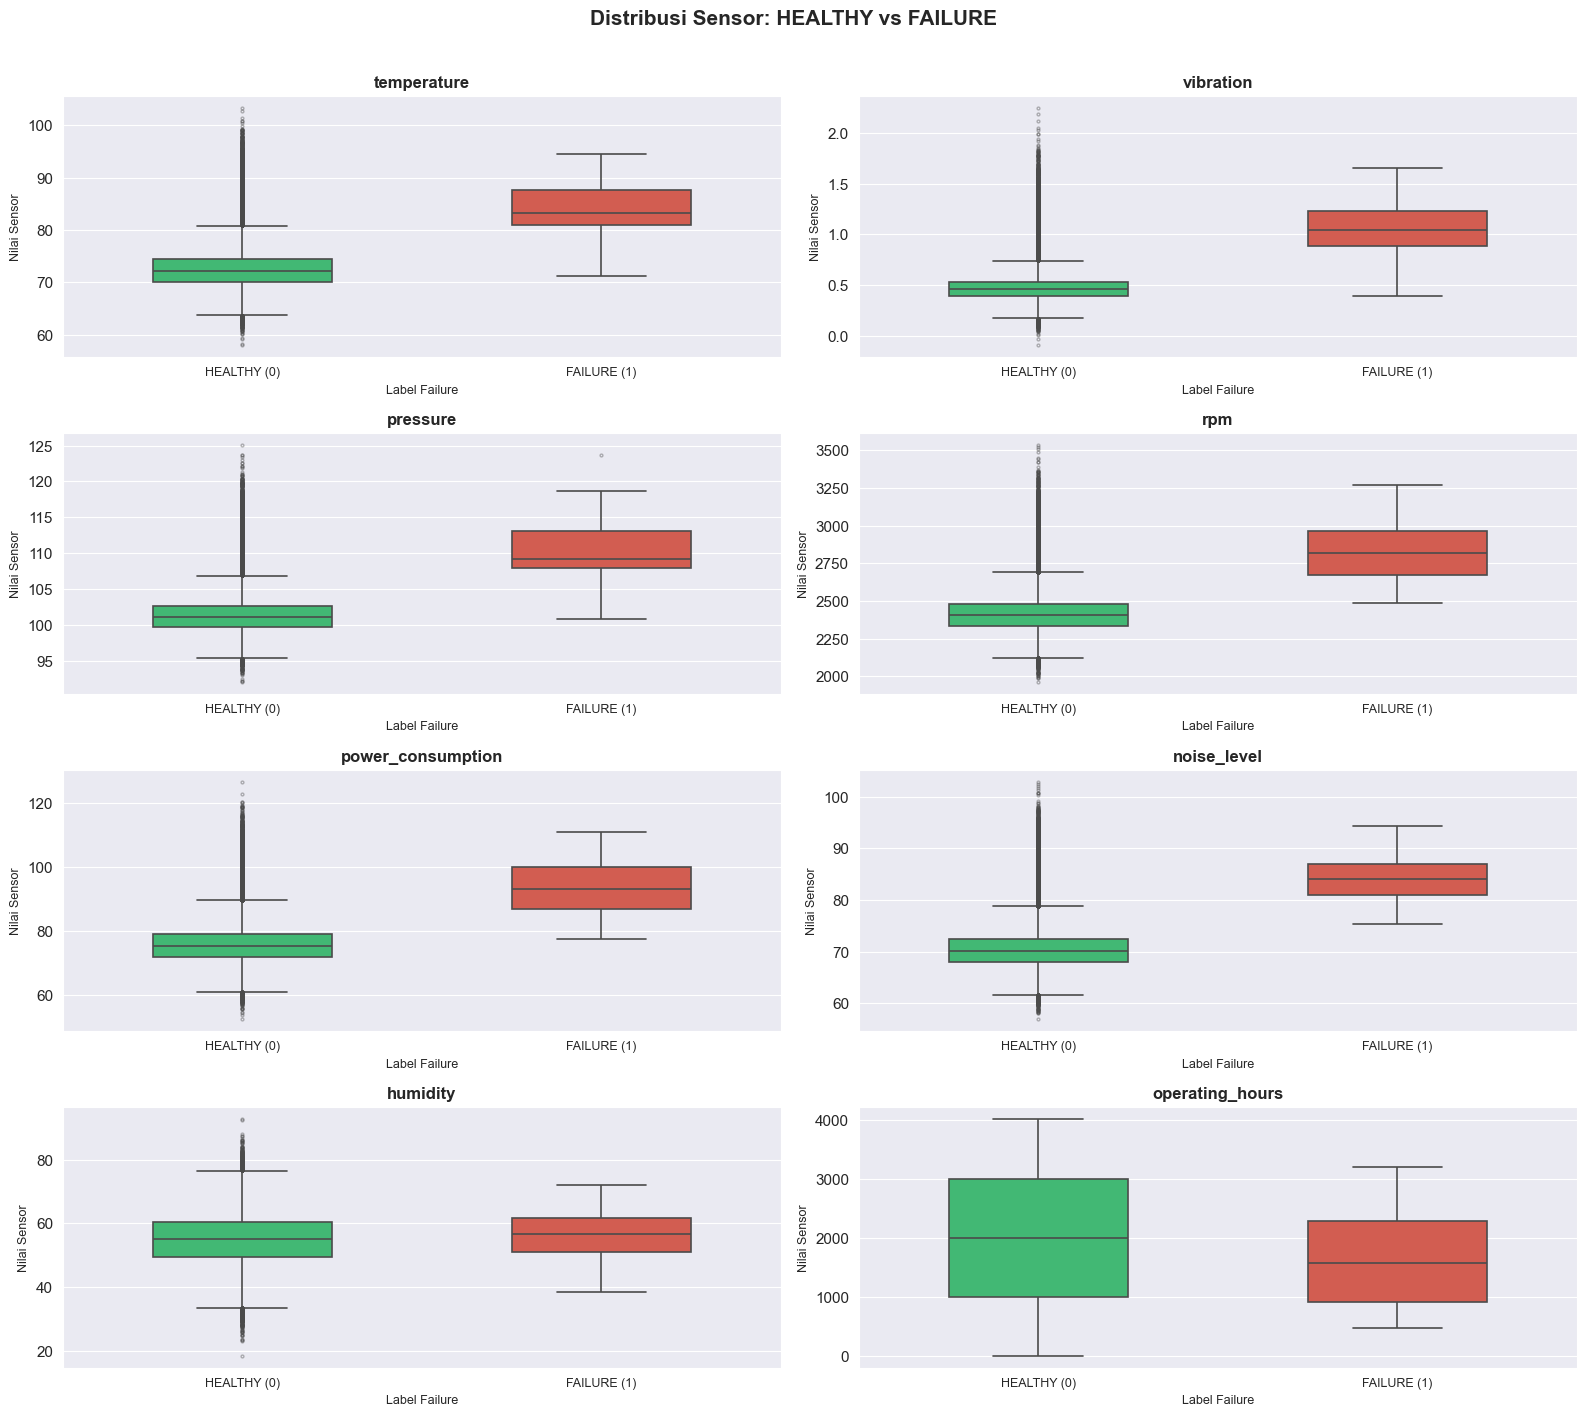


  BAGIAN 2 - COHEN'S D EFFECT SIZE

           sensor  cohens_d effect_size_category
        vibration    3.3662   Besar (Fitur Kuat)
         pressure    3.0581   Besar (Fitur Kuat)
              rpm    2.9144   Besar (Fitur Kuat)
      noise_level    2.8883   Besar (Fitur Kuat)
      temperature    2.7085   Besar (Fitur Kuat)
power_consumption    2.6129   Besar (Fitur Kuat)
  operating_hours    0.2858               Sedang
         humidity    0.2055               Sedang

-----------------------------------------------------------------
  REKOMENDASI
-----------------------------------------------------------------

  [KONFIRMASI FITUR KUAT]  d >= 0.5 :
    - vibration               d = 3.3662
    - pressure                d = 3.0581
    - rpm                     d = 2.9144
    - noise_level             d = 2.8883
    - temperature             d = 2.7085
    - power_consumption       d = 2.6129

  Tidak ada sensor dengan effect size kecil (d < 0.2).

  [OK] Sensor Informativeness Tes

In [4]:
# ============================================================
# FASE 2 - SENSOR INFORMATIVENESS TEST
# Cell 3: Boxplot distribusi + Cohen's d effect size
# ============================================================

import math

SEP = "=" * 65
sep = "-" * 65

SENSOR_COLS = [
    "temperature",
    "vibration",
    "pressure",
    "rpm",
    "power_consumption",
    "noise_level",
    "humidity",
    "operating_hours",
]

# Defensive: hanya gunakan kolom yang benar-benar ada
sensor_cols_ok = [c for c in SENSOR_COLS if c in df_sensor.columns]

# Label x-axis yang deskriptif untuk boxplot
XTICKLABELS = ["HEALTHY (0)", "FAILURE (1)"]

# Palette: hijau = healthy, merah = failure
PALETTE = ["#2ecc71", "#e74c3c"]

# ============================================================
# BAGIAN 1 - BOXPLOT DISTRIBUSI PER LABEL
# ============================================================
print(SEP)
print("  BAGIAN 1 - BOXPLOT: HEALTHY vs FAILURE")
print(SEP)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 14),
)
axes_flat = axes.flatten()

for idx, sensor in enumerate(sensor_cols_ok):
    ax = axes_flat[idx]

    sns.boxplot(
        data=df_sensor,
        x="failure",
        y=sensor,
        palette=PALETTE,
        ax=ax,
        order=[0, 1],
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker="o", markersize=2, alpha=0.4),
    )

    ax.set_title(sensor, fontsize=12, fontweight="bold")
    ax.set_xlabel("Label Failure", fontsize=9)
    ax.set_ylabel("Nilai Sensor", fontsize=9)
    ax.set_xticklabels(XTICKLABELS, fontsize=9)

# Sembunyikan subplot kosong
for idx in range(len(sensor_cols_ok), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    "Distribusi Sensor: HEALTHY vs FAILURE",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# ============================================================
# BAGIAN 2 - COHEN'S D EFFECT SIZE
# ============================================================
print(f"\n{SEP}")
print("  BAGIAN 2 - COHEN'S D EFFECT SIZE")
print(SEP)

# ----------------------------------------------------------
# Helper: hitung Cohen's d dengan pooled std
# ----------------------------------------------------------
def cohens_d(group_0, group_1):
    """
    Hitung Cohen's d (absolute) antara dua group.
    pooled_std = sqrt(((n1-1)*std1^2 + (n2-1)*std2^2) / (n1+n2-2))
    d = abs(mean1 - mean0) / pooled_std
    """
    n0, n1   = len(group_0), len(group_1)
    mean0    = group_0.mean()
    mean1    = group_1.mean()
    std0     = group_0.std(ddof=1)
    std1     = group_1.std(ddof=1)

    pooled_var = ((n0 - 1) * std0 ** 2 + (n1 - 1) * std1 ** 2) / (n0 + n1 - 2)
    pooled_std = math.sqrt(pooled_var)

    if pooled_std == 0:
        return 0.0
    return abs(mean1 - mean0) / pooled_std


# ----------------------------------------------------------
# Helper: kategorisasi effect size
# ----------------------------------------------------------
def effect_size_category(d):
    if d < 0.2:
        return "Kecil (Kandidat Drop)"
    elif d < 0.5:
        return "Sedang"
    else:
        return "Besar (Fitur Kuat)"


# ----------------------------------------------------------
# Hitung untuk setiap sensor
# ----------------------------------------------------------
group_healthy = df_sensor[df_sensor["failure"] == 0]
group_failure = df_sensor[df_sensor["failure"] == 1]

results = []
for sensor in sensor_cols_ok:
    g0 = group_healthy[sensor].dropna()
    g1 = group_failure[sensor].dropna()
    d  = cohens_d(g0, g1)
    results.append({
        "sensor"               : sensor,
        "cohens_d"             : round(d, 4),
        "effect_size_category" : effect_size_category(d),
    })

df_cohens = (
    pd.DataFrame(results)
    .sort_values("cohens_d", ascending=False)
    .reset_index(drop=True)
)

print()
print(df_cohens.to_string(index=False))

# ----------------------------------------------------------
# Print rekomendasi
# ----------------------------------------------------------
kandidat_drop = df_cohens[df_cohens["cohens_d"] < 0.2]["sensor"].tolist()
fitur_kuat    = df_cohens[df_cohens["cohens_d"] >= 0.5]["sensor"].tolist()

print(f"\n{sep}")
print("  REKOMENDASI")
print(sep)

if fitur_kuat:
    print(f"\n  [KONFIRMASI FITUR KUAT]  d >= 0.5 :")
    for s in fitur_kuat:
        d_val = df_cohens.loc[df_cohens["sensor"] == s, "cohens_d"].values[0]
        print(f"    - {s:<22}  d = {d_val:.4f}")
else:
    print("\n  Tidak ada sensor dengan effect size besar (d >= 0.5).")

if kandidat_drop:
    print(f"\n  [KANDIDAT DROP]  d < 0.2 :")
    for s in kandidat_drop:
        d_val = df_cohens.loc[df_cohens["sensor"] == s, "cohens_d"].values[0]
        print(f"    - {s:<22}  d = {d_val:.4f}")
else:
    print("\n  Tidak ada sensor dengan effect size kecil (d < 0.2).")

print(f"\n{SEP}")
print("  [OK] Sensor Informativeness Test selesai.")
print(SEP)